# log(시장점유율) + LightGBM/SHAP 가중치

log(가입자수) 그대로 쓴 회귀는 상관관계는 보여줘도 "왜 골랐는가"는 설명 못 한다.
로짓(효용 극대화) 가정에서 시장점유율은 log(share) 형태로 역산된다 — y를 이 형태로
바꾸고 LightGBM+SHAP으로 비선형·조합 효과까지 반영한다. `regression_baseline.ipynb`
(구 `eda+weigths.ipynb`)는 건드리지 않음, 완전 별도 파일.

비용은 `cost6`(6개월 블렌드) 대신 이번 달 실부담(`discounted_fee`)을 그대로 씀.

한계: outside option을 몰라서 완전한 BLP 역산은 아님. 단일 시점이라 브랜드 고정효과까지만
넣고 요금제 단위 가격 내생성은 못 없앰. 노출 순서 편향은 데이터가 없어서 다루지 않음.

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)

DATA = Path("../data")
plans = pd.read_csv(DATA / "통신요금제_통합데이터_최종.csv", dtype={"plan_id": str})
benefits = pd.read_csv(DATA / "통신요금제_혜택상세_최종.csv", dtype={"plan_id": str})
prices = pd.read_csv(DATA / "ott_prices.csv")
price_map = dict(zip(prices.service, prices.monthly_won.astype(int)))

print(f"plans {len(plans):,}행 · benefits {len(benefits):,}행 · OTT 가격표 {len(prices)}개")

plans 2,759행 · benefits 5,581행 · OTT 가격표 13개


In [2]:
# 학습 모집단: carrier_type=MVNO 인데 mvno_brand 가 SKT/KT/LG U+ 인 45개는
# 실은 통신 3사 온라인 전용 상품(regression_baseline.ipynb 3-1 참고) — 제외한다
mvno_all = plans[plans.carrier_type == "MVNO"].copy()
MNO_BRANDS = ["SKT", "KT", "LG U+", "LGU+"]
mvno = mvno_all[~mvno_all.mvno_brand.isin(MNO_BRANDS)].copy()
print(f"알뜰폰 {len(mvno_all):,}개 -> 오분류 45개 제외 -> {len(mvno):,}개")

알뜰폰 2,203개 -> 오분류 45개 제외 -> 2,158개


In [3]:
# cost는 cost6 대신 이번 달 실부담(discounted_fee). sms_cnt는 회귀에서 계수가
# 음수라 뺐었는데, EDA 산점도로 보니 900대에서 꺾이는 비선형이라 다시 넣는다.
def qos_mbps(value):
    if pd.isna(value):
        return 0.0
    m = re.match(r"([\d.]+)\s*(kbps|mbps)", str(value).strip().lower().replace(" ", ""))
    if not m:
        return 0.0
    n = float(m.group(1))
    return n / 1000 if m.group(2) == "kbps" else n


def build(df):
    d = df.copy()
    d["cost_month"] = d.discounted_fee

    extra = benefits[benefits.benefit_category == "추가데이터"].copy()
    extra["gb"] = extra.benefit_name.fillna("").str.extract(r"([\d.]+)\s*GB", flags=re.I)[0].astype(float)
    d["extra_gb"] = d.plan_id.map(extra.groupby("plan_id").gb.sum()).fillna(0)
    d["data_total_gb"] = np.where(
        d.data_unlimited, 300,
        (d.data_gb.fillna(d.daily_data_gb.fillna(0) * 30) + d.extra_gb).clip(0, 300)
    )
    d["qos"] = d.data_throttle_speed.map(qos_mbps)
    d["tether_gb"] = d.tethering_gb.fillna(0)
    d["voice_min"] = np.where(d.voice_unlimited, 1000, d.voice_minutes.fillna(0)).clip(0, 1000)
    d["sms_cnt"] = np.where(d.sms_unlimited, 1000, d.sms_count.fillna(0)).clip(0, 1000)

    ott_b = benefits[benefits.benefit_service.isin(price_map)]  # 카테고리명이 바뀌어(2026-09-16 크롤러 수정) 서비스명 매칭으로 변경
    ott_services = d.plan_id.map(
        ott_b.groupby("plan_id")["benefit_service"].apply(lambda v: sorted(set(v.dropna())))
    )
    d["ott_value"] = ott_services.apply(
        lambda services: sum(price_map.get(s, 0) for s in services) if isinstance(services, list) else 0
    )
    return d


mvno = build(mvno)
AXES = ["cost_month", "data_total_gb", "qos", "tether_gb", "voice_min", "sms_cnt", "ott_value"]
mvno[AXES].describe().T[["mean", "std", "min", "max"]].round(1)

,mean,std,min,max
cost_month,15923.7,11939.9,0.0,57200.0
data_total_gb,42.9,50.0,0.1,250.0
qos,2.0,2.1,0.0,10.0
tether_gb,3.0,11.1,0.0,100.0
voice_min,631.3,416.0,0.0,1000.0
sms_cnt,583.0,442.7,0.0,1000.0
ott_value,480.2,2295.9,0.0,11900.0


In [4]:
# y = log(시장점유율). "이 알뜰폰 요금제 중 하나를 고른다" 는 닫힌 선택지로 본다.
mvno["market_share"] = mvno.subscriber_count / mvno.subscriber_count.sum()
y_share = np.log(mvno["market_share"].clip(lower=1e-12).values)
print(f"학습 표본 {len(mvno):,}개 · 점유율 합 {mvno.market_share.sum():.4f}"
      f" · log_share 범위 [{y_share.min():.2f}, {y_share.max():.2f}]")

학습 표본 2,158개 · 점유율 합 1.0000 · log_share 범위 [-12.51, -3.32]


In [5]:
# 피처: 7축(원 단위, 트리모델이라 정규화 불필요) + 브랜드 더미(고정효과, 가중치엔 미포함)
import lightgbm as lgb

brand_dummies = pd.get_dummies(mvno.mvno_brand, prefix="brand", dummy_na=True)
features = pd.concat(
    [mvno[AXES].reset_index(drop=True), brand_dummies.reset_index(drop=True)], axis=1
)

gbm = lgb.LGBMRegressor(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    min_child_samples=20, random_state=0, verbosity=-1,
)
gbm.fit(features, y_share)
print(f"학습 표본 {len(features):,}개 · 피처 {features.shape[1]}개"
      f"(축 {len(AXES)} + 브랜드 더미 {brand_dummies.shape[1]})")

학습 표본 2,158개 · 피처 35개(축 7 + 브랜드 더미 28)


In [6]:
# SHAP — 축별 평균 |기여도| 를 정규화해 가중치로 쓴다
import shap

explainer = shap.TreeExplainer(gbm)
shap_values = explainer.shap_values(features)

axis_importance = np.abs(shap_values[:, :len(AXES)]).mean(axis=0)
brand_importance = np.abs(shap_values[:, len(AXES):]).mean(axis=0).sum()

WEIGHTS = pd.Series(axis_importance, index=AXES)
WEIGHTS = (WEIGHTS / WEIGHTS.sum()).sort_values(ascending=False)

print("축별 가중치(SHAP 기반, cost=1개월 실부담):")
for name, value in WEIGHTS.items():
    print(f"   {name:<14} {value:.3f}")
share = brand_importance / (axis_importance.sum() + brand_importance)
print(f"\n브랜드 고정효과 기여(참고용, 가중치엔 미포함): {brand_importance:.4f} (전체 대비 {share:.1%})")

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


축별 가중치(SHAP 기반, cost=1개월 실부담):
   cost_month     0.472
   data_total_gb  0.273
   qos            0.099
   voice_min      0.064
   sms_cnt        0.045
   ott_value      0.026
   tether_gb      0.021

브랜드 고정효과 기여(참고용, 가중치엔 미포함): 0.7106 (전체 대비 23.3%)


## 안정적인가 — 부트스트랩

요금제를 복원추출로 60번 다시 뽑아 LightGBM을 매번 새로 학습하고 SHAP도 다시 계산한다.

In [7]:
# 60회 재학습이라 몇 분 걸릴 수 있음
rng = np.random.default_rng(0)
n = len(features)
boot_rows = []
for i in range(60):
    idx = rng.choice(n, size=n, replace=True)
    m = lgb.LGBMRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        min_child_samples=20, random_state=i, verbosity=-1,
    )
    m.fit(features.iloc[idx], y_share[idx])
    sv = shap.TreeExplainer(m).shap_values(features.iloc[idx])
    imp = np.abs(sv[:, :len(AXES)]).mean(axis=0)
    boot_rows.append(imp / imp.sum())

boot = pd.DataFrame(boot_rows, columns=AXES)
summary = pd.DataFrame({
    "추정치": WEIGHTS, "부트 평균": boot.mean(), "표준편차": boot.std(),
    "2.5%": boot.quantile(0.025), "97.5%": boot.quantile(0.975),
}).reindex(WEIGHTS.index)
print(summary.round(3).to_string())

assert abs(WEIGHTS.sum() - 1.0) < 1e-9
assert set(WEIGHTS.index) == set(AXES)

                 추정치  부트 평균   표준편차   2.5%  97.5%
cost_month     0.472  0.464  0.012  0.442  0.485
data_total_gb  0.273  0.265  0.022  0.218  0.304
qos            0.099  0.100  0.022  0.064  0.141
voice_min      0.064  0.079  0.020  0.044  0.120
sms_cnt        0.045  0.046  0.011  0.028  0.065
ott_value      0.026  0.025  0.006  0.016  0.038
tether_gb      0.021  0.021  0.006  0.008  0.032


## EDA — 축과 y 관계를 산점도로 먼저 확인

지금까지 상관·VIF는 변수끼리만 봤고, 변수 하나하나가 log_share랑 실제로 관계가
있는지는 안 봤음. 7개 원본 변수(sms_cnt 포함) 전부 log_share랑 산점도로 찍어본다.

점이 2,158개라 겹쳐서 모양이 안 보이니, 15구간(qcut)으로 나눠 구간 평균을 빨간
선으로 같이 그림 — 직선인지, 로그형으로 꺾이는지, 관계가 없는지 이 선으로 판단한다.

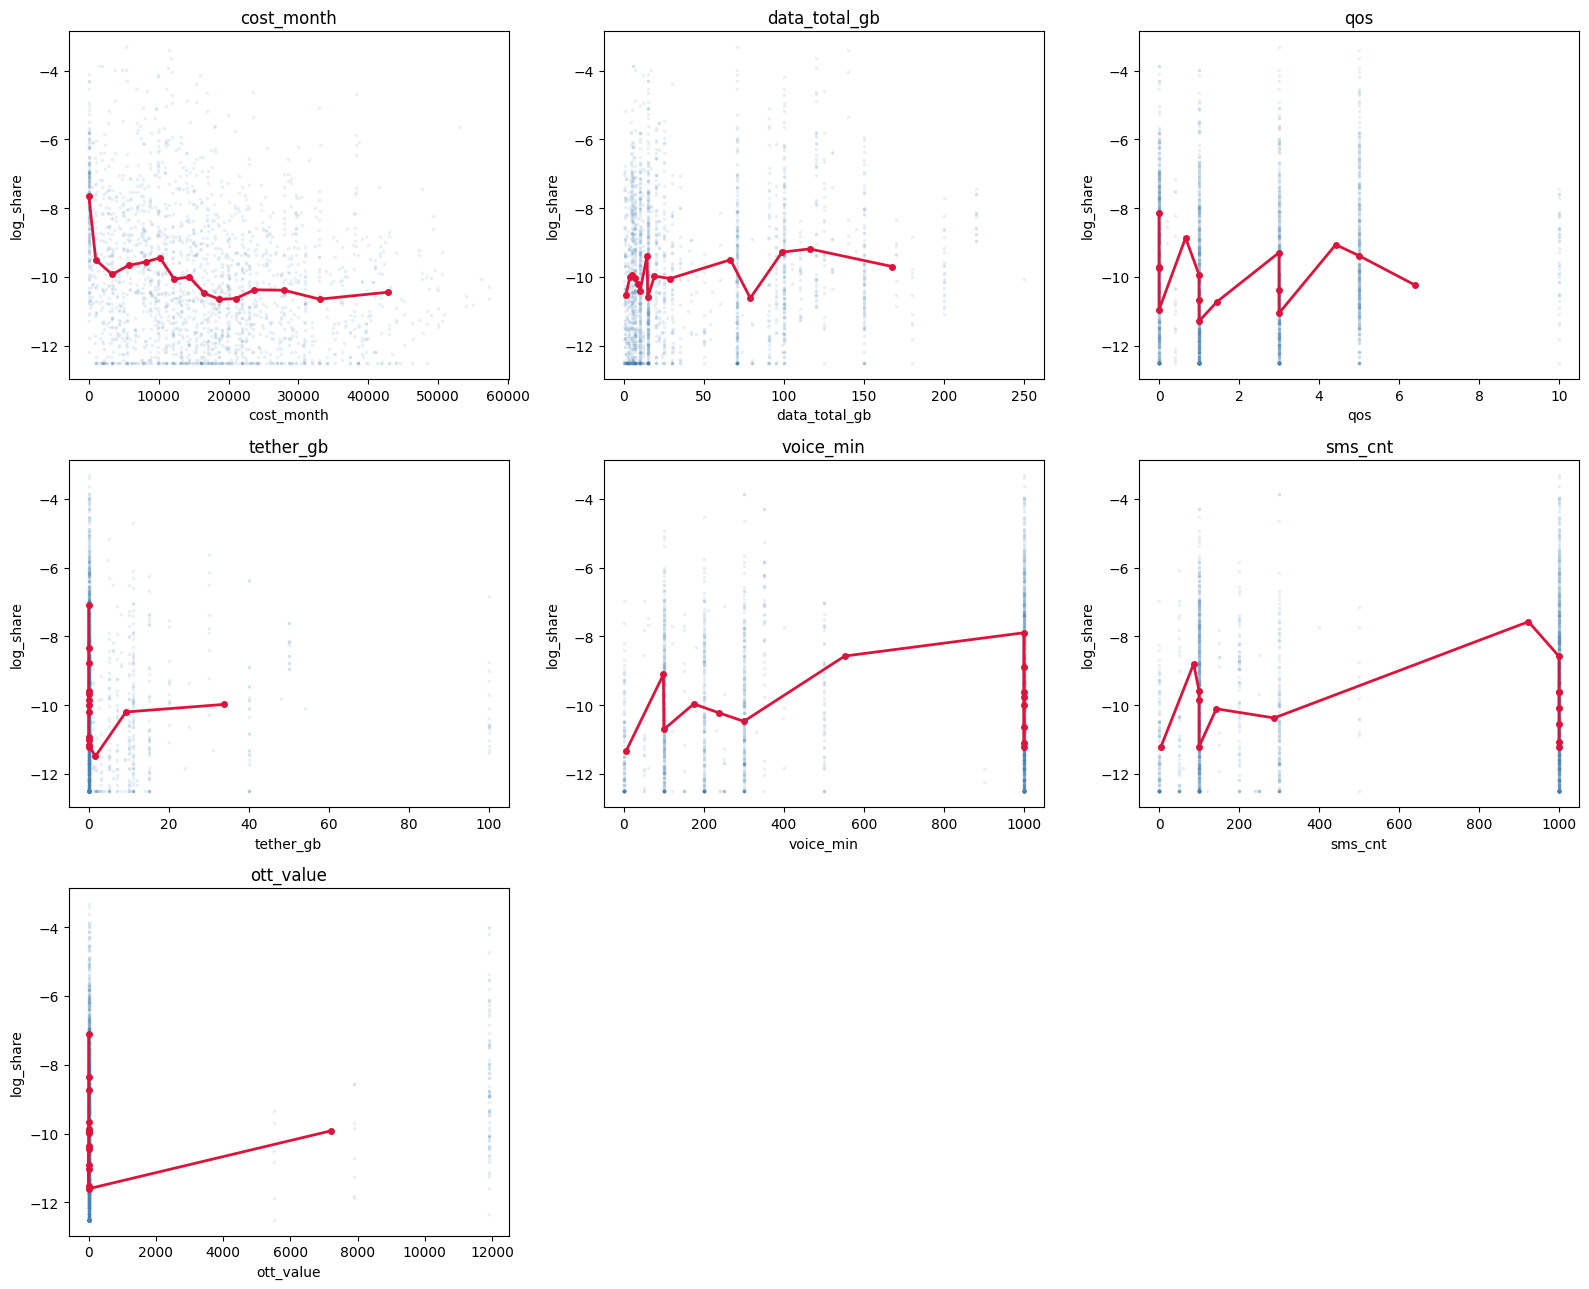

In [8]:
import matplotlib.pyplot as plt

RAW_VARS = ["cost_month", "data_total_gb", "qos", "tether_gb", "voice_min", "sms_cnt", "ott_value"]

fig, grid = plt.subplots(3, 3, figsize=(16, 13))
grid = grid.flatten()
for i, col in enumerate(RAW_VARS):
    ax = grid[i]
    x = mvno[col]
    ax.scatter(x, y_share, s=6, alpha=0.12, color="steelblue", linewidths=0)

    bins = pd.qcut(x.rank(method="first"), q=15, duplicates="drop")
    binned = pd.DataFrame({"x": x, "y": y_share, "bin": bins}).groupby("bin", observed=True).agg(
        x_mean=("x", "mean"), y_mean=("y", "mean")
    )
    ax.plot(binned.x_mean, binned.y_mean, color="crimson", linewidth=2, marker="o", markersize=4)
    ax.set_xlabel(col)
    ax.set_ylabel("log_share")
    ax.set_title(col)
for j in range(len(RAW_VARS), len(grid)):
    fig.delaxes(grid[j])
plt.tight_layout()
plt.savefig("scatter_raw_vs_logshare.png", dpi=110)
plt.show()